In [5]:
import pandas as pd
import pyodbc

connection = pyodbc.connect(
    r"Driver={SQL Server};"
    r"Server=ADEKUNLE-ADEOYE\SQLEXPRESS01;"
    r"Database=NorDexManufacturing2;"
    r"Trusted_Connection=yes;"
)

In [8]:
query = "SELECT * FROM vw_shift_performance_dataset"
df = pd.read_sql(query, connection)

df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_18076\2828872785.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,production_id,date,shift_id,shift_name,start_time,end_time,supervisor_id,machine_id,runtime_hours,downtime_minutes,machine_status,maintenance_flag,operator_id,operator_name,experience_level,skill_category,units_produced,defect_count,cycle_time_avg,shift_efficiency_score
0,1,2024-01-01,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,MC_001,7.24,15.39,Operational,0,OP_019,Operator_19,7,Expert,929,20,35.65,95.945255
1,2,2024-01-01,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,MC_002,7.13,22.27,Operational,0,OP_033,Operator_33,12,Expert,873,16,39.41,92.909529
2,3,2024-01-01,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,MC_003,7.16,20.21,Operational,0,OP_069,Operator_69,6,Senior,904,20,36.89,95.297638
3,4,2024-01-01,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,MC_004,7.29,12.35,Operational,0,OP_090,Operator_90,7,Expert,930,16,36.74,100.096832
4,5,2024-01-01,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,MC_005,7.24,15.86,Operational,0,OP_051,Operator_51,7,Senior,867,22,33.18,93.381354


In [9]:
df.shape

(13650, 20)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13650 entries, 0 to 13649
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   production_id           13650 non-null  int64  
 1   date                    13650 non-null  object 
 2   shift_id                13650 non-null  int64  
 3   shift_name              13650 non-null  object 
 4   start_time              13650 non-null  object 
 5   end_time                13650 non-null  object 
 6   supervisor_id           13650 non-null  object 
 7   machine_id              13650 non-null  object 
 8   runtime_hours           13650 non-null  float64
 9   downtime_minutes        13650 non-null  float64
 10  machine_status          13650 non-null  object 
 11  maintenance_flag        13650 non-null  int64  
 12  operator_id             13650 non-null  object 
 13  operator_name           13650 non-null  object 
 14  experience_level        13650 non-null

In [11]:
df.describe()

,production_id,shift_id,runtime_hours,downtime_minutes,maintenance_flag,experience_level,units_produced,defect_count,cycle_time_avg,shift_efficiency_score
count,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000,13650.000000
mean,6825.500000,2.000000,6.676292,49.415453,0.138974,4.222125,644.176484,20.237729,36.020648,76.247519
std,3940.559922,0.816526,0.326934,19.625838,0.345932,2.525720,155.786956,2.933802,1.966767,12.988072
min,1.000000,1.000000,5.900000,10.000000,0.000000,1.000000,414.000000,13.000000,32.000000,41.690033
25%,3413.250000,1.000000,6.440000,35.582500,0.000000,2.000000,511.000000,18.000000,34.650000,65.086264
50%,6825.500000,2.000000,6.640000,51.575000,0.000000,4.000000,599.000000,20.000000,36.005000,76.641687
75%,10237.750000,3.000000,6.910000,63.770000,0.000000,6.000000,817.000000,22.000000,37.360000,88.079370
max,13650.000000,3.000000,7.330000,95.710000,1.000000,12.000000,972.000000,29.000000,42.000000,104.379285


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

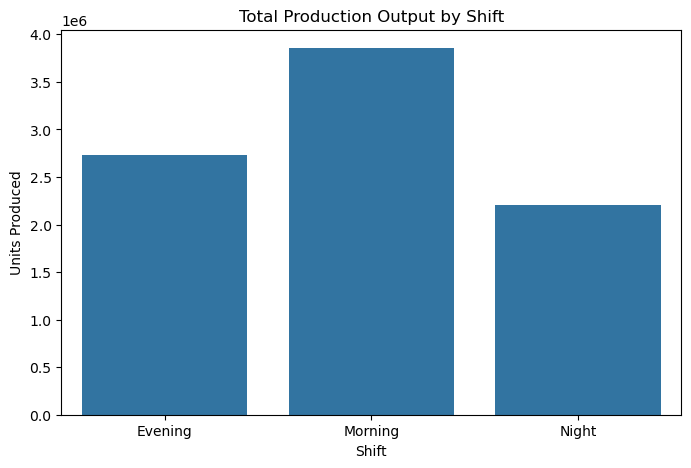

In [13]:
shift_output = df.groupby('shift_name')['units_produced'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=shift_output, x='shift_name', y='units_produced')

plt.title("Total Production Output by Shift")
plt.xlabel("Shift")
plt.ylabel("Units Produced")

plt.show()

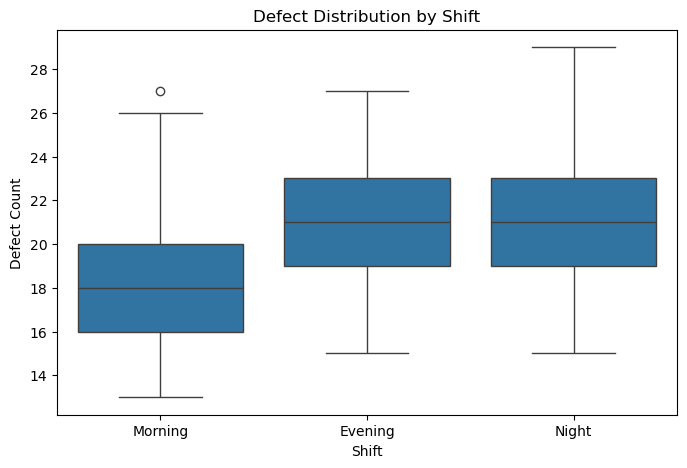

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='shift_name', y='defect_count')

plt.title("Defect Distribution by Shift")
plt.xlabel("Shift")
plt.ylabel("Defect Count")

plt.show()

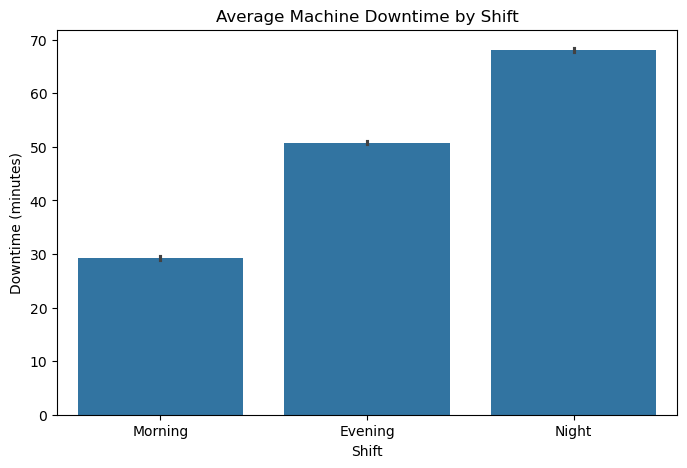

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='shift_name', y='downtime_minutes')

plt.title("Average Machine Downtime by Shift")
plt.xlabel("Shift")
plt.ylabel("Downtime (minutes)")

plt.show()

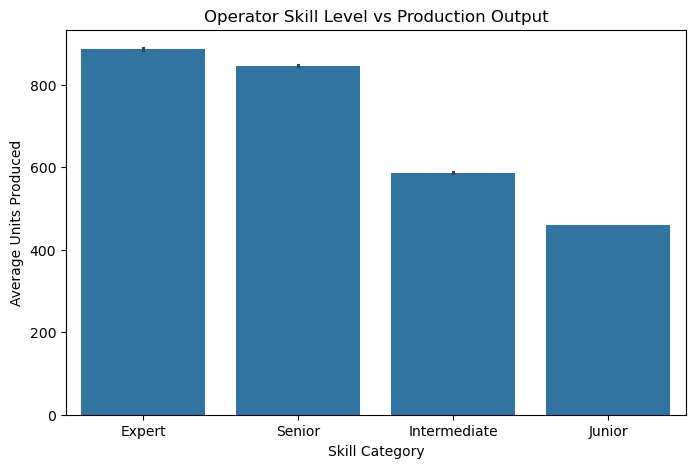

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='skill_category', y='units_produced')

plt.title("Operator Skill Level vs Production Output")
plt.xlabel("Skill Category")
plt.ylabel("Average Units Produced")

plt.show()

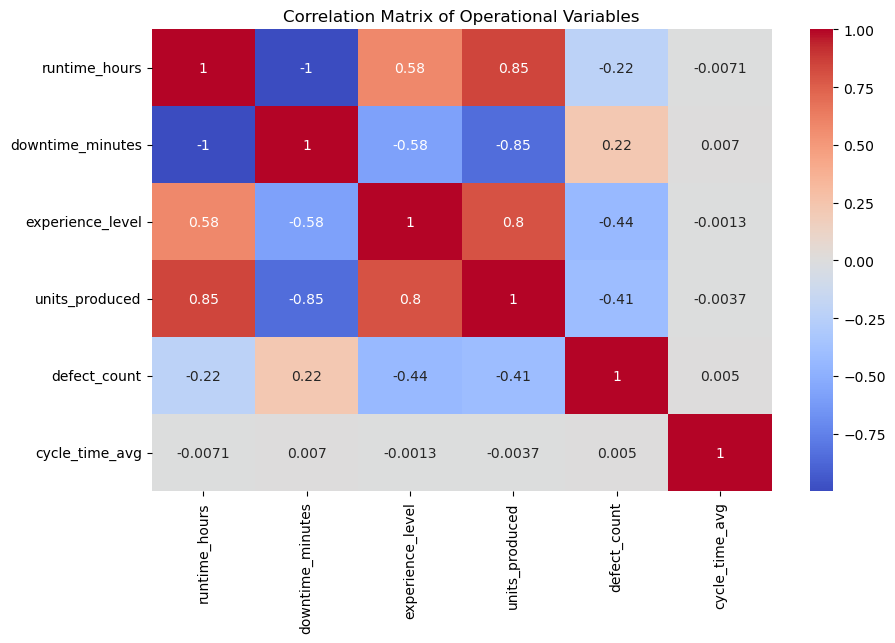

In [17]:
numeric_df = df[['runtime_hours','downtime_minutes','experience_level',
                 'units_produced','defect_count','cycle_time_avg']]

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix of Operational Variables")

plt.show()

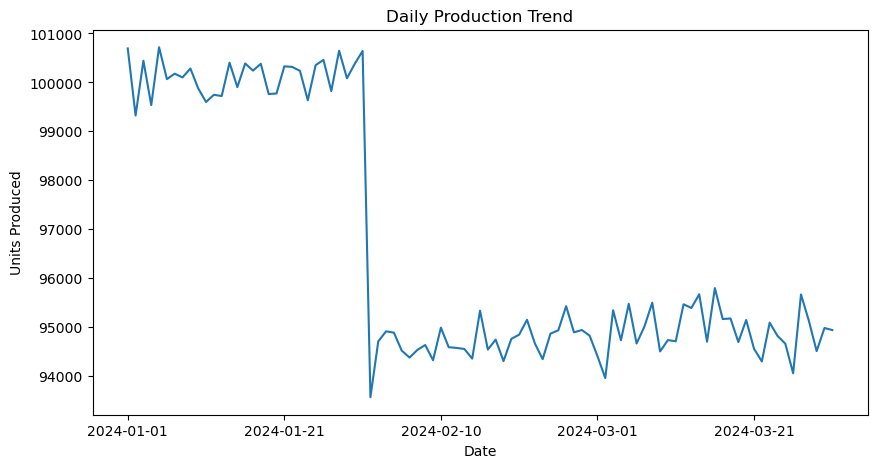

In [18]:
daily_production = df.groupby('date')['units_produced'].sum()

plt.figure(figsize=(10,5))
daily_production.plot()

plt.title("Daily Production Trend")
plt.xlabel("Date")
plt.ylabel("Units Produced")

plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [20]:
features = df[['runtime_hours','downtime_minutes','experience_level',
               'units_produced','defect_count','cycle_time_avg']]

target = df['shift_efficiency_score']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

In [22]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [23]:
predictions = model.predict(X_test)

In [24]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 3.6799971405010075
R2 Score: 0.8733586715750238


In [25]:
coefficients = pd.DataFrame({
    'Feature': features.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
0,runtime_hours,37.660382
1,downtime_minutes,0.493545
3,units_produced,0.068815
5,cycle_time_avg,-0.017286
4,defect_count,-0.060034
2,experience_level,-0.443261


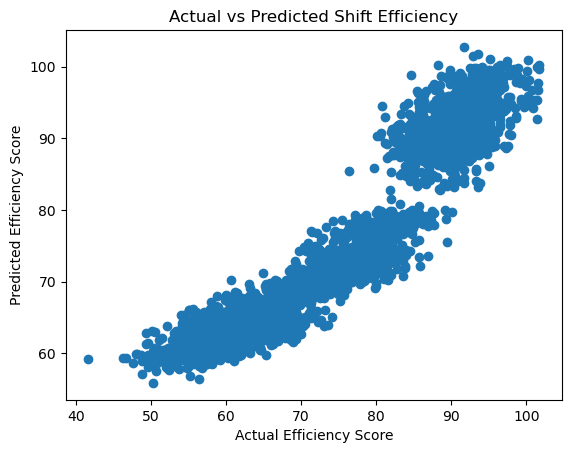

In [26]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Efficiency Score")
plt.ylabel("Predicted Efficiency Score")
plt.title("Actual vs Predicted Shift Efficiency")

plt.show()